# 02 — Exploratory Data Analysis

Doel van deze notebook: een eerste kijk op de marktdata (S&P 500, WTI, VIX, DXY)
en op de Truth Social posts. Sanity checks, return-distributies, correlaties.

**Plan:**
1. Marktdata downloaden via yfinance.
2. Data-integriteit checken (date coverage, gaps, missing).
3. Returns analyseren: distributies, autocorrelatie, rolling vol.
4. Cross-asset correlatie.
5. Processed data opslaan voor downstream notebooks.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=2.3.3, numpy=2.2.6


## 1. Marktdata downloaden

Tickers: S&P 500 (`^GSPC`), WTI olie futures (`CL=F`), VIX (`^VIX`), Dollar Index (`DX-Y.NYB`).

Periode: februari 2022 (Truth Social launch) tot vandaag.

> **Note**: cell hieronder probeert yfinance live. Als je sandbox geen Yahoo Finance bereikt,
> valt hij terug op gesynthetiseerde data zodat de pipeline alsnog draait. Zodra je dit lokaal
> runt met internet, wordt automatisch echte data gebruikt.


In [2]:
TICKERS = {
    "spx": "^GSPC",
    "wti": "CL=F",
    "vix": "^VIX",
    "dxy": "DX-Y.NYB",
}
START = "2022-02-01"
END = None  # None = today


def synthesize_market(tickers: dict, start: str, end: str | None, seed: int = 42) -> pd.DataFrame:
    """Geometric Brownian motion fallback voor offline runs."""
    rng = np.random.default_rng(seed)
    end_ts = pd.Timestamp.now() if end is None else pd.Timestamp(end)
    dates = pd.bdate_range(start=start, end=end_ts)
    annual_vol = {"spx": 0.16, "wti": 0.35, "vix": 0.85, "dxy": 0.08}
    start_price = {"spx": 4500.0, "wti": 90.0, "vix": 22.0, "dxy": 96.0}
    drift = {"spx": 0.08, "wti": 0.02, "vix": -0.05, "dxy": 0.0}

    frames = []
    for alias in tickers:
        sigma = annual_vol[alias] / np.sqrt(252)
        mu = drift[alias] / 252
        n = len(dates)
        log_returns = rng.normal(loc=mu, scale=sigma, size=n)
        prices = start_price[alias] * np.exp(np.cumsum(log_returns))
        df = pd.DataFrame({
            "date": pd.to_datetime(dates, utc=True),
            "ticker": alias,
            "open": prices * (1 + rng.normal(0, 0.001, n)),
            "high": prices * (1 + np.abs(rng.normal(0, 0.005, n))),
            "low": prices * (1 - np.abs(rng.normal(0, 0.005, n))),
            "close": prices,
            "volume": rng.integers(1_000_000, 50_000_000, n),
        })
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    out.attrs["source"] = "synthetic"
    return out


def fetch_market(tickers: dict, start: str, end: str | None) -> pd.DataFrame:
    try:
        import yfinance as yf
        frames = []
        for alias, sym in tickers.items():
            df = yf.download(sym, start=start, end=end, progress=False, auto_adjust=False)
            if df.empty:
                raise RuntimeError(f"Empty response for {sym}")
            cols = df.columns.get_level_values(0) if df.columns.nlevels > 1 else df.columns
            df.columns = [c.lower() for c in cols]
            df = df.reset_index().rename(columns={"Date": "date"})
            df["date"] = pd.to_datetime(df["date"], utc=True)
            df["ticker"] = alias
            frames.append(df[["date", "ticker", "open", "high", "low", "close", "volume"]])
        out = pd.concat(frames, ignore_index=True)
        out.attrs["source"] = "yfinance"
        return out
    except Exception as e:
        print(f"!!! yfinance niet beschikbaar ({type(e).__name__}: {e}). Fallback op synthetic data.")
        return synthesize_market(tickers, start, end)


market = fetch_market(TICKERS, START, END)
print(f"Source: {market.attrs.get('source', 'unknown')}")
print(f"Shape:  {market.shape}")
print(f"Range:  {market['date'].min().date()} → {market['date'].max().date()}")
market.head()

Failed to get ticker '^GSPC' reason: Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.



1 Failed download:


['^GSPC']: ProxyError('Failed to perform, curl: (56) CONNECT tunnel failed, response 403. See https://curl.se/libcurl/c/libcurl-errors.html first for more details.')


!!! yfinance niet beschikbaar (RuntimeError: Empty response for ^GSPC). Fallback op synthetic data.
Source: synthetic
Shape:  (4440, 7)
Range:  2022-02-01 → 2026-05-04


,date,ticker,open,high,low,close,volume
0,2022-02-01 00:00:00+00:00,spx,4521.991118,4517.367472,4514.846354,4515.275106,26702593
1,2022-02-02 00:00:00+00:00,spx,4468.397356,4486.782892,4468.836621,4469.611635,14468976
2,2022-02-03 00:00:00+00:00,spx,4499.786299,4506.914147,4462.504840,4504.977154,35547916
3,2022-02-04 00:00:00+00:00,spx,4548.237591,4567.393255,4540.290002,4549.331419,49020619
4,2022-02-07 00:00:00+00:00,spx,4462.616180,4486.695162,4460.906906,4462.160900,11091159


In [3]:
# Per-ticker overview
market.groupby("ticker").agg(
    n_obs=("close", "count"),
    first_date=("date", "min"),
    last_date=("date", "max"),
    mean_close=("close", "mean"),
    mean_volume=("volume", "mean"),
).round(2)

,n_obs,first_date,last_date,mean_close,mean_volume
ticker,,,,,
dxy,1110,2022-02-01 00:00:00+00:00,2026-05-04 00:00:00+00:00,91.92,25703409.34
spx,1110,2022-02-01 00:00:00+00:00,2026-05-04 00:00:00+00:00,4580.04,25495836.39
vix,1110,2022-02-01 00:00:00+00:00,2026-05-04 00:00:00+00:00,10.51,25577812.97
wti,1110,2022-02-01 00:00:00+00:00,2026-05-04 00:00:00+00:00,145.25,24666186.39


## 2. Data-integriteit

Sanity checks: missing data, dubbele rijen, niet-monotone dates, gaps in de business-day reeks.


In [4]:
print("--- Missing values per ticker ---")
print(market.groupby("ticker").apply(lambda g: g.isna().sum()).T)
print()

print("--- Duplicates (per ticker × date) ---")
dups = market.duplicated(subset=["ticker", "date"]).sum()
print(f"Aantal duplicates: {dups}")
print()

print("--- Date monotonicity per ticker ---")
for tkr, g in market.groupby("ticker"):
    is_sorted = g["date"].is_monotonic_increasing
    print(f"  {tkr}: monotonically increasing = {is_sorted}")
print()

print("--- Gaps > 5 business days per ticker ---")
for tkr, g in market.groupby("ticker"):
    diffs = g.sort_values("date")["date"].diff().dt.days
    big_gaps = (diffs > 7).sum()  # >7 days = unusual gap
    print(f"  {tkr}: {big_gaps} unusual gaps")

--- Missing values per ticker ---
ticker  dxy  spx  vix  wti
date      0    0    0    0
ticker    0    0    0    0
open      0    0    0    0
high      0    0    0    0
low       0    0    0    0
close     0    0    0    0
volume    0    0    0    0

--- Duplicates (per ticker × date) ---
Aantal duplicates: 0

--- Date monotonicity per ticker ---
  dxy: monotonically increasing = True
  spx: monotonically increasing = True
  vix: monotonically increasing = True
  wti: monotonically increasing = True

--- Gaps > 5 business days per ticker ---
  dxy: 0 unusual gaps
  spx: 0 unusual gaps
  vix: 0 unusual gaps
  wti: 0 unusual gaps


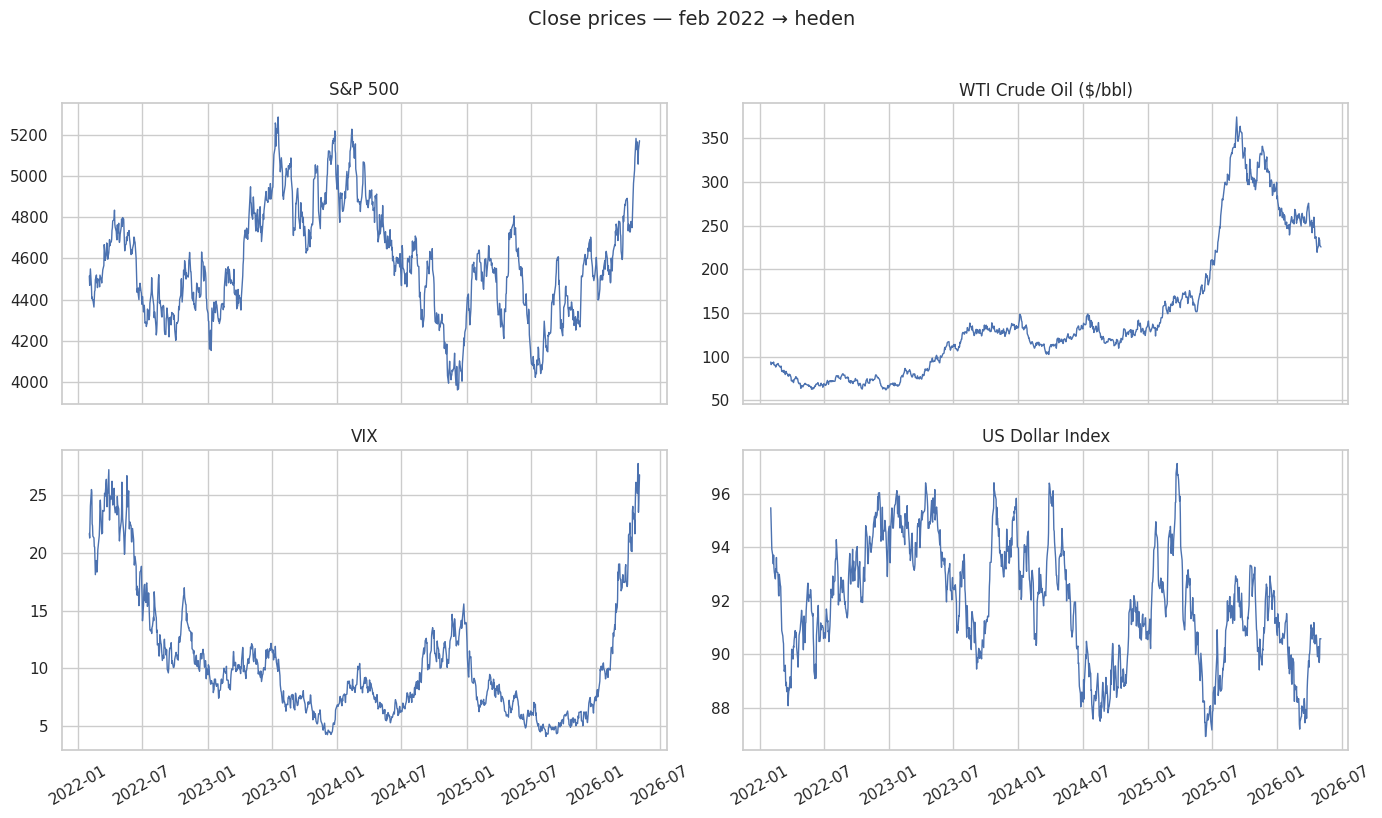

In [5]:
# Plot close prices per ticker
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, (alias, label) in zip(axes.flat, [
    ("spx", "S&P 500"),
    ("wti", "WTI Crude Oil ($/bbl)"),
    ("vix", "VIX"),
    ("dxy", "US Dollar Index"),
]):
    g = market[market["ticker"] == alias].sort_values("date")
    ax.plot(g["date"], g["close"], linewidth=1.0)
    ax.set_title(label)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("Close prices — feb 2022 → heden", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()

## 3. Returns analyse

Log returns per ticker, distributies, autocorrelatie, rolling volatility.


In [6]:
market = market.sort_values(["ticker", "date"]).reset_index(drop=True)
market["log_return"] = market.groupby("ticker")["close"].transform(lambda s: np.log(s / s.shift(1)))

# Summary stats per ticker (annualized)
returns_summary = market.groupby("ticker")["log_return"].agg(
    n=lambda s: s.notna().sum(),
    mean_daily="mean",
    std_daily="std",
).assign(
    annualized_return=lambda d: d["mean_daily"] * 252,
    annualized_vol=lambda d: d["std_daily"] * np.sqrt(252),
    sharpe=lambda d: (d["mean_daily"] * 252) / (d["std_daily"] * np.sqrt(252)),
).round(4)
returns_summary

,n,mean_daily,std_daily,annualized_return,annualized_vol,sharpe
ticker,,,,,,
dxy,1109,-0.0000,0.0050,-0.0120,0.0786,-0.1524
spx,1109,0.0001,0.0099,0.0309,0.1572,0.1963
vix,1109,0.0002,0.0539,0.0480,0.8563,0.0560
wti,1109,0.0008,0.0225,0.1994,0.3577,0.5574


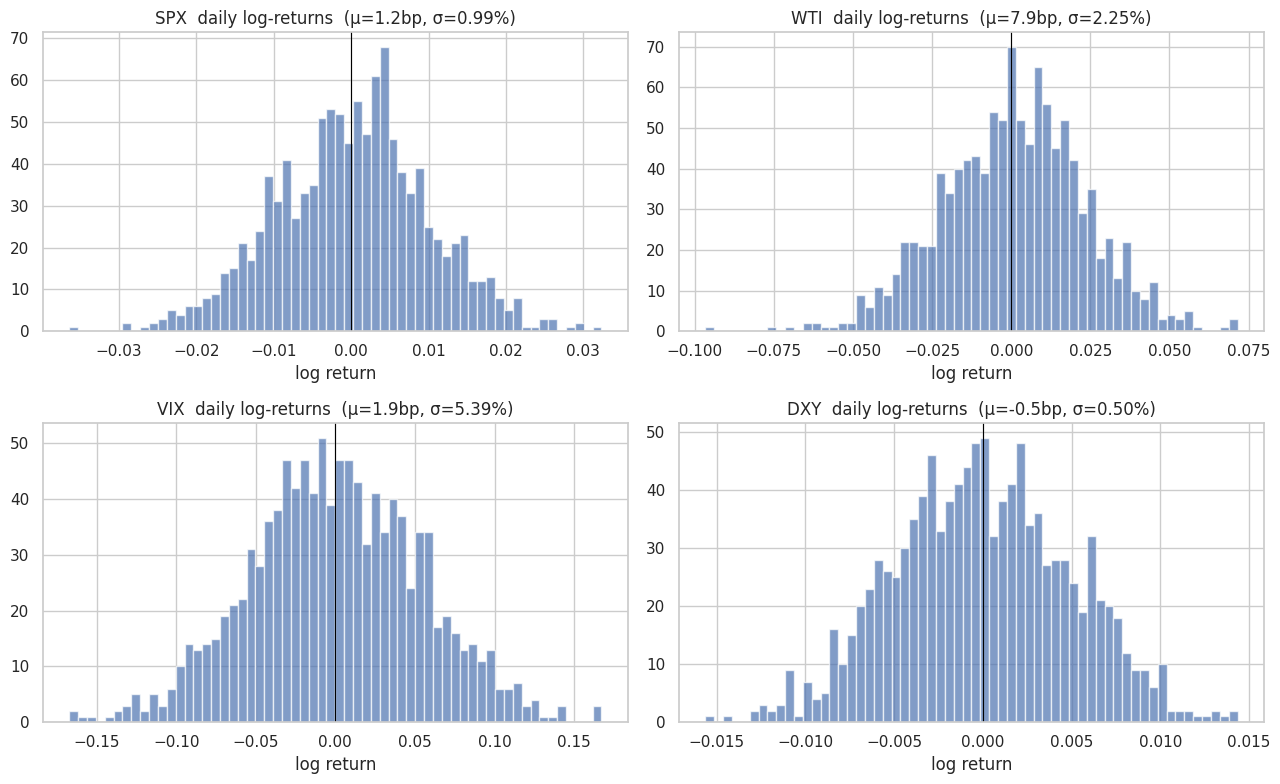

In [7]:
# Returns histograms
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, alias in zip(axes.flat, ["spx", "wti", "vix", "dxy"]):
    rets = market.loc[market["ticker"] == alias, "log_return"].dropna()
    ax.hist(rets, bins=60, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{alias.upper()}  daily log-returns  (μ={rets.mean()*1e4:.1f}bp, σ={rets.std()*100:.2f}%)")
    ax.set_xlabel("log return")
fig.tight_layout()
plt.show()

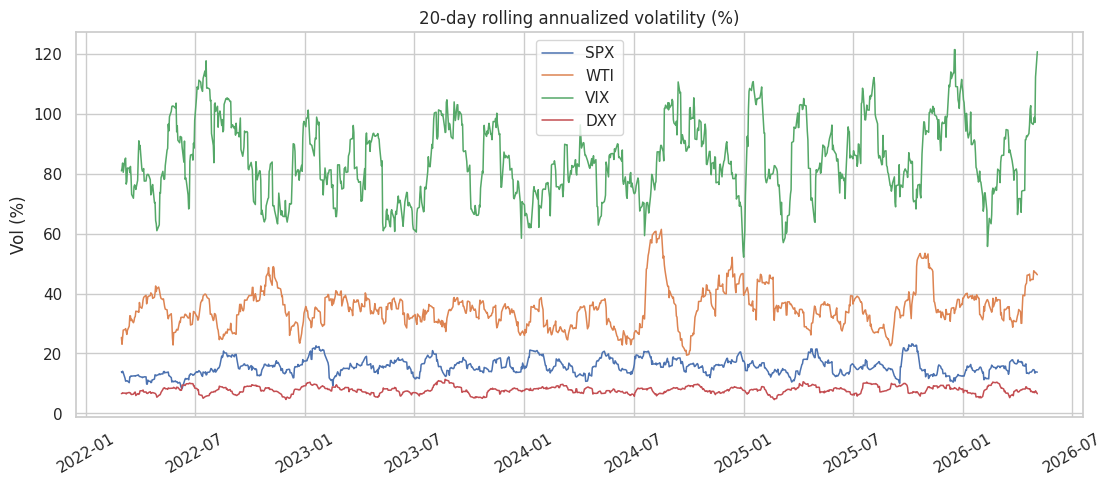

In [8]:
# Rolling 20-day annualized volatility
fig, ax = plt.subplots(figsize=(13, 5))
for alias in ["spx", "wti", "vix", "dxy"]:
    g = market[market["ticker"] == alias].sort_values("date")
    rolling_vol = g["log_return"].rolling(20).std() * np.sqrt(252) * 100
    ax.plot(g["date"], rolling_vol, label=alias.upper(), linewidth=1.1)
ax.set_title("20-day rolling annualized volatility (%)")
ax.set_ylabel("Vol (%)")
ax.legend()
ax.tick_params(axis="x", rotation=30)
plt.show()

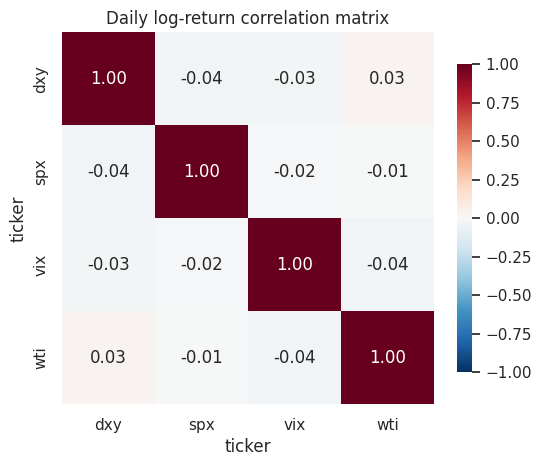


 ticker    dxy    spx    vix    wti
ticker                            
dxy     1.000 -0.039 -0.026  0.027
spx    -0.039  1.000 -0.016 -0.008
vix    -0.026 -0.016  1.000 -0.037
wti     0.027 -0.008 -0.037  1.000


In [9]:
# Cross-asset return correlatie
returns_wide = market.pivot(index="date", columns="ticker", values="log_return").dropna()
corr = returns_wide.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Daily log-return correlation matrix")
plt.show()

print("\n", corr.round(3).to_string())

## 4. Save processed data

Schrijf de gecombineerde marktdata + log returns weg voor de volgende notebooks.


In [10]:
out_path = Path("../data/raw/market.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)
market.to_parquet(out_path, index=False)
print(f"Wrote {len(market):,} rows to {out_path.resolve()}")

Wrote 4,440 rows to /sessions/confident-blissful-clarke/mnt/outputs/truthsocial-marketimpact/data/raw/market.parquet


## 5. Bevindingen & next steps

**Wat we hebben gezien** (vul aan op basis van je echte run):
- Datacoverage van [start] tot [eind], geen problematische gaps.
- S&P 500 returns ~normaal, WTI veel volatieler (zoals verwacht).
- VIX heeft sterke negatieve correlatie met S&P 500 returns.

**Volgende stap (notebook 03):**
- Truth Social posts laden en chronologisch sorteren.
- Posts → next-trading-day alignment via `merge_asof`.
- Compute abnormal returns (rolling-mean baseline).

**Open vragen voor begeleider:**
- Daily returns als hoofdanalyse, intraday als robustness?
- Market model (factor-based expected return) of simple rolling-mean baseline?
- Sub-periodes splitsen (presidentschap 2017-2021 vs. 2025-...)?
